# 🏖️Resort Churn Prediction
## Predicting loyalty churn at a luxury all-inclusive resort

## Project Overview
Steve's Luxury Resorts is a premium all-inclusive resort chain operating across three major regions. The resort has identified a recurring problem: a significant share of guests are not returning for future stays or are cancelling their loyalty memberships shortly after their visit. Early identification of at-risk guests would allow the resort to intervene with targeted retention campaigns before churn occurs.
This project builds a classification model to predict which guests are likely to churn based on booking behavior, on-site spending patterns, and loyalty engagement data.

This project was completed as part of **Machine Learning and AI**, a component of the **Master of Management Analytics curriculum at Queen's University.**

## Competition Context
This project was structured as a Kaggle competition among teams in the program. Models were evaluated on a held-out test set scored automatically by Kaggle using the F1 metric. The leaderboard provided real-time feedback on generalization performance.

|          |       |
|----------|---------------------------------|
|Platform | Kaggle - Steve's Luxury Resorts |
|Evaluation metric | F1 score |
|Training set | 6,954 guests |
|Test set | 1,739 |
|Final leaderboard F1 | 0.850 |
|Estimated F1 (Cross-validation) | 0.8519 |

## Objectives

**Primary objective:** Predict which resort guests are likely to churn, defined as cancelling their loyalty membership or not returning for a future stay, using booking behavior, on-site spending patterns, and loyalty engagement data.

**Secondary objective:** Identify which modeling and optimization techniques contribute most to F1 performance and quantify the incremental gain of each, from baseline model to hyperparameter tuning, threshold optimization, seed bagging, and ensemble blending.

## Analytical Competencies Demonstrated

1. Exploratory Data Analysis (EDA) — distribution analysis, spending pattern exploration, and feature correlation
2. Feature engineering — temporal features from booking date, room attribute parsing, spending aggregates, zero-spend flags, and spending share ratios
3. Data preprocessing — log transformation of skewed spending variables, median imputation for numerics, one-hot encoding for categorical features, all implemented inside a sklearn Pipeline to prevent data leakage
4. Model selection — systematic comparison of Logistic Regression, Random Forest, and HistGradientBoosting using stratified cross-validation
5. Hyperparameter tuning — RandomizedSearchCV over 50 candidates with 5-fold stratified CV
6. Threshold optimization — F1-optimal decision threshold search over out-of-fold predictions
7. Seed bagging — variance reduction by averaging predictions across multiple random seeds
8. Ensemble blending — weighted combination of HistGradientBoosting and LightGBM with optimized blend weights

 ## 1. Import Libraries and Load data

In [38]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Sklearn - Model Selection & Validation
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Models
from sklearn.ensemble import (
    HistGradientBoostingClassifier, RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression

# Try LightGBM
try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except:
    LGBM_AVAILABLE = False
    print('⚠ LightGBM not available')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported!')
print(f'   LightGBM: {LGBM_AVAILABLE}')

✅ All libraries imported!
   LightGBM: True


In [39]:
# Load data
TRAIN_PATH = 'https://raw.githubusercontent.com/stepthom/869_course/refs/heads/main/data/resort_train.csv'
TEST_PATH = 'https://raw.githubusercontent.com/stepthom/869_course/refs/heads/main/data/resort_test.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'\nChurn rate: {train_df["Churned"].mean():.2%}')

train_df.head()

Train shape: (6954, 21)
Test shape: (1739, 20)

Churn rate: 50.36%


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,...,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,...,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,...,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,...,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,...,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,...,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


## 2. Exploratory Data Anlysis

In [40]:
### 2.1 Dataset Info
print('TRAINING SET')
print(f'Shape: {train_df.shape}')
print()
train_df.info()

TRAINING SET
Shape: (6954, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GuestID         6954 non-null   int64  
 1   BookingDate     6954 non-null   object 
 2   PromoCode       3709 non-null   object 
 3   Region          6785 non-null   object 
 4   AllInclusive    6786 non-null   float64
 5   Room            6568 non-null   object 
 6   PackageType     6801 non-null   object 
 7   Age             6478 non-null   float64
 8   VIP             6796 non-null   float64
 9   RoomService     6490 non-null   float64
 10  Dining          6466 non-null   float64
 11  Retail          6790 non-null   float64
 12  Spa             6806 non-null   float64
 13  Entertainment   6815 non-null   float64
 14  LoyaltyPoints   6954 non-null   int64  
 15  SurveyScore     6954 non-null   int64  
 16  DaysSinceEmail  6954 non-null   int64  
 17  B

In [41]:
### 2.2 Statistical Summary
print('Numerical Features — Statistical Summary')
train_df.describe().round(2)

Numerical Features — Statistical Summary


,GuestID,AllInclusive,Age,VIP,RoomService,Dining,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,Churned
count,6954.00,6786.00,6478.00,6796.00,6490.00,6466.00,6790.00,6806.00,6815.00,6954.00,6954.00,6954.00,6954.0
mean,544815.12,0.36,28.68,0.02,3823.69,7651.36,5980.80,5728.86,6757.87,5037.92,2.99,183.18,0.5
std,258449.78,0.48,14.53,0.15,26416.09,54005.99,43130.40,41105.73,46162.31,2870.17,1.42,104.56,0.5
min,100000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.0
25%,322043.25,0.00,19.00,0.00,0.00,0.00,0.00,0.00,0.00,2566.25,2.00,93.00,0.0
50%,542402.50,0.00,27.00,0.00,0.00,0.00,0.00,0.00,0.00,5055.50,3.00,183.00,1.0
75%,769552.75,1.00,38.00,0.00,84.00,95.00,37.75,80.00,67.00,7496.75,4.00,273.00,1.0
max,999943.00,1.00,79.00,1.00,282324.95,590932.01,468882.33,447858.85,482032.27,9996.00,5.00,364.00,1.0


In [42]:
### 2.3 Missing Values
# Count missing values
train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()

missing_df = pd.DataFrame({
    'Train Missing': train_missing,
    'Train %': (train_missing / len(train_df) * 100).round(2),
    'Test Missing': test_missing,
    'Test %': (test_missing / len(test_df) * 100).round(2)
})

missing_df = missing_df[missing_df['Train Missing'] + missing_df['Test Missing'] > 0]

if missing_df.empty:
    print('No missing values found in either dataset.')
else:
    print('Columns with missing values:')
    print(missing_df)


Columns with missing values:
               Train Missing  Train %  Test Missing  Test %
Age                      476     6.84         127.0    7.30
AgeGroup                 283     4.07          74.0    4.26
AllInclusive             168     2.42          49.0    2.82
Dining                   488     7.02         125.0    7.19
Entertainment            139     2.00          44.0    2.53
PackageType              153     2.20          29.0    1.67
PromoCode               3245    46.66         788.0   45.31
Region                   169     2.43          32.0    1.84
Retail                   164     2.36          39.0    2.24
Room                     386     5.55          88.0    5.06
RoomService              464     6.67         112.0    6.44
Spa                      148     2.13          32.0    1.84
VIP                      158     2.27          45.0    2.59


PromoCode shows ~47% missing in both train and test. This is treated as a separate category, a dedicated binary flag (promo_missing) is created in feature engineering to capture this signal explicitly.

All other features show low missingness (2–7%), consistent across train and test, suggesting no data drift in missing patterns. Handled via median imputation (numerical) and most_frequent imputation (categorical) inside the pipeline.

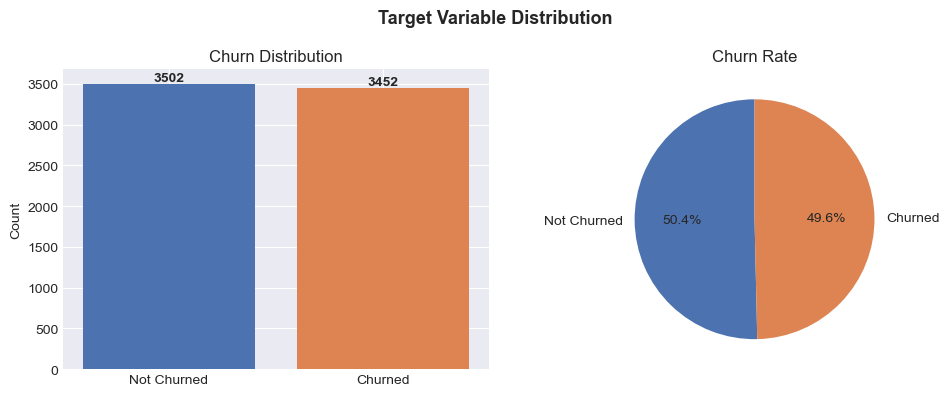


Churn rate: 50.36%


In [43]:
### 2.4 Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
churn_counts = train_df['Churned'].value_counts()
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Percentage plot
churn_pct = train_df['Churned'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90)
axes[1].set_title('Churn Rate')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nChurn rate: {train_df["Churned"].mean():.2%}')

The target variable is nearly perfectly balanced: 50.4% not churned vs 49.6% churned; this eliminates the need for class imbalance techniques such as oversampling or class_weight adjustments.

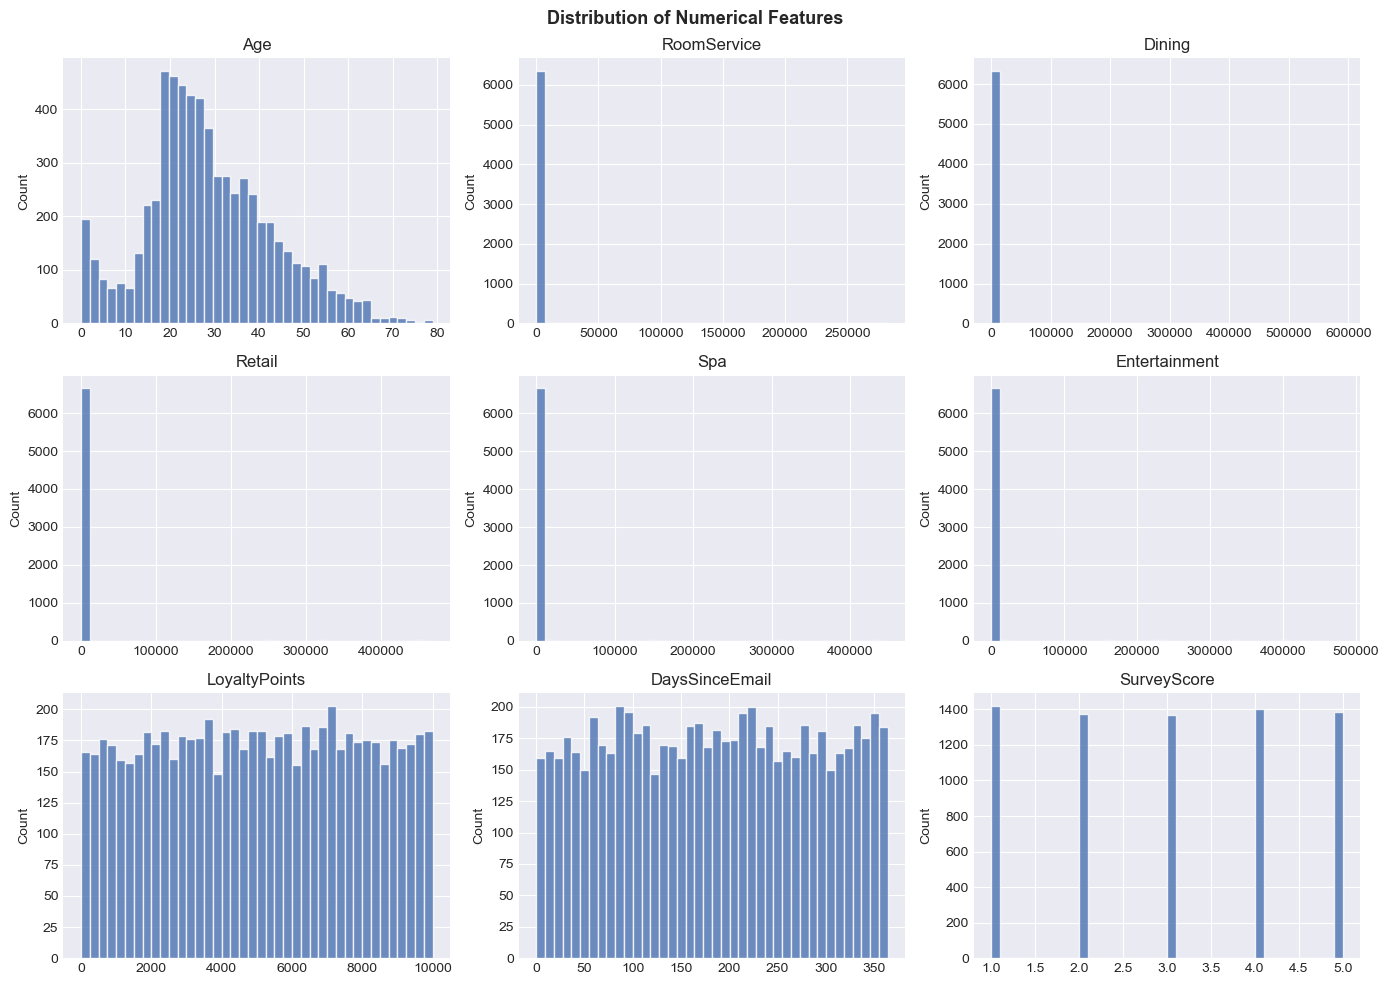

In [44]:
### 2.5 Distribution of Numerical Features
numerical_cols = ['Age', 'RoomService', 'Dining', 'Retail', 'Spa',
                  'Entertainment', 'LoyaltyPoints', 'DaysSinceEmail', 'SurveyScore']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(train_df[col].dropna(), bins=40,
                 color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

All five spending variables (Room service, Dining, Retail, Spa and Entertainment) are heavily right-skewed, most guests spend zero or near zero, with a long tail of high spenders. This directly motivates the log1p transformation applied in feature engineering.

LoyaltyPoints and DaysSinceEmail are approximately uniform; the log1p transformation has minimal impact on these variables.

SurveyScore is discrete (1–5) and approximately uniform across categories.

Age shows a bimodal pattern with an unexpected concentration near 0–10, which may reflect data entry anomalies worth investigating.

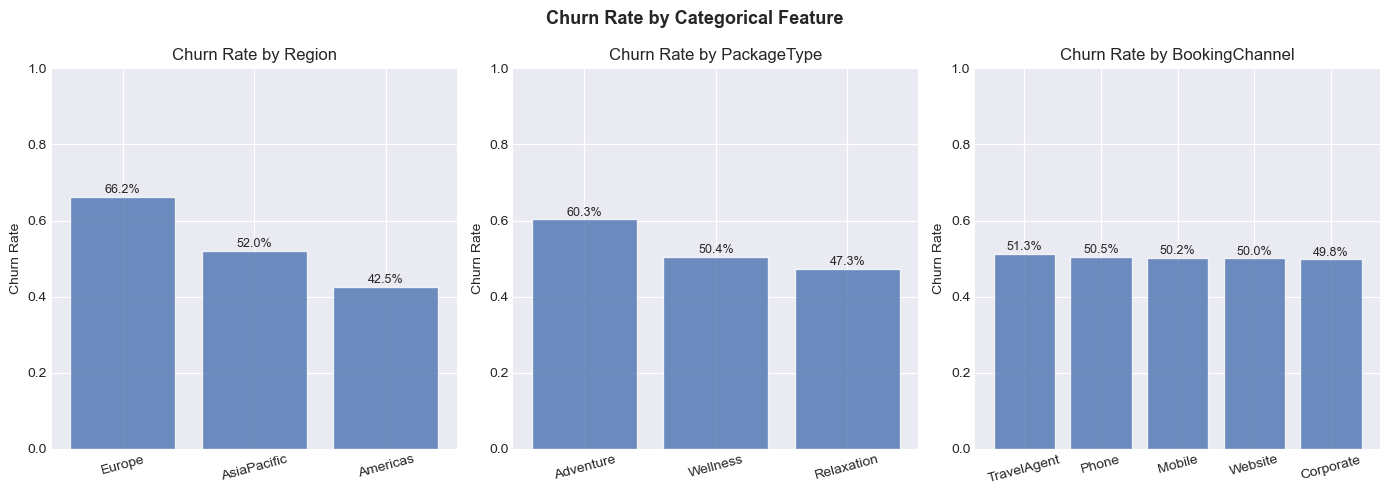

In [45]:
### 2.6 Categorical Features
cat_cols = ['Region', 'PackageType', 'BookingChannel']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    churn_rate = train_df.groupby(col)['Churned'].mean().sort_values(ascending=False)
    
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=15)
    
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     val + 0.01, f'{val:.1%}',
                     ha='center', fontsize=9)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Region shows the strongest signal, European guests churn at 66.2%, nearly double the rate of Americas guests (42.5%).

PackageType shows moderate separation, Adventure guests churn at 60.3% vs 47.3% for Relaxation.

BookingChannel shows almost no variation across categories (49.8%–51.3%), suggesting limited predictive value for this feature.

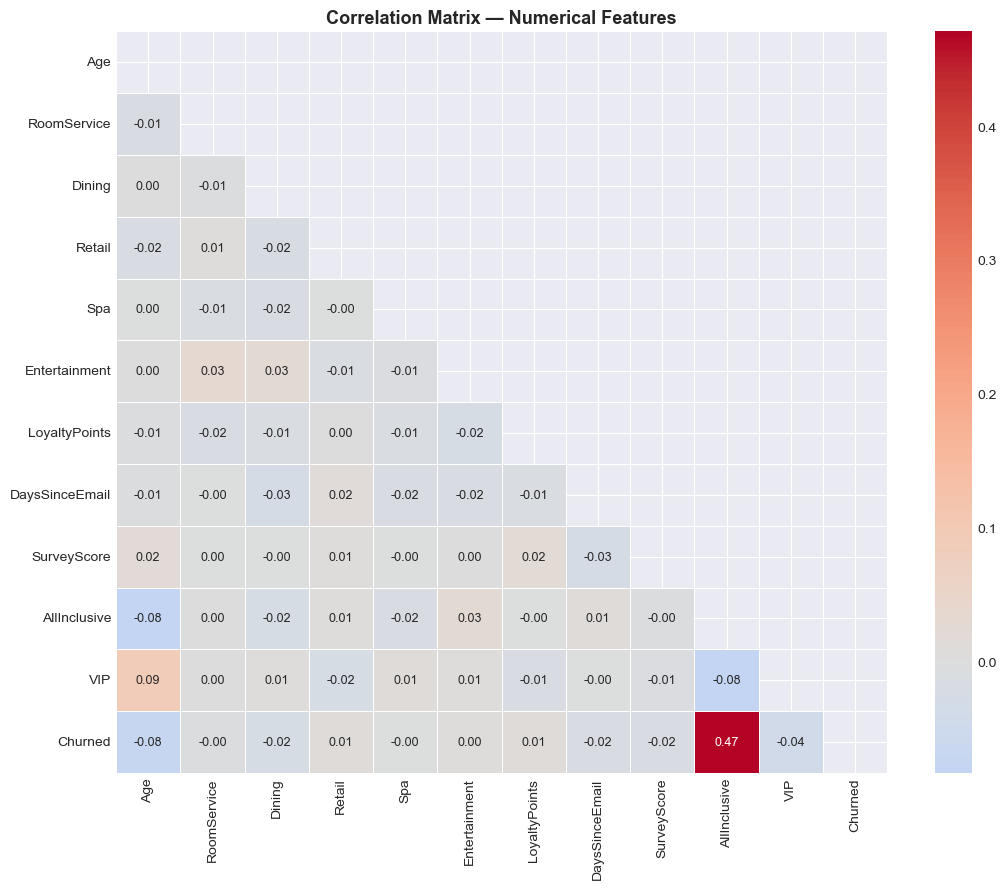

In [46]:
### 2.7 Correlation Matrix
numerical_for_corr = ['Age', 'RoomService', 'Dining', 'Retail', 'Spa',
                      'Entertainment', 'LoyaltyPoints', 'DaysSinceEmail',
                      'SurveyScore', 'AllInclusive', 'VIP', 'Churned']

corr_matrix = train_df[numerical_for_corr].astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

AllInclusive shows the strongest correlation with Churned (0.47), guests on the all-inclusive package churn at a significantly higher rate. This is counterintuitive from a business perspective and warrants further investigation.

All other numerical features show near-zero correlation with Churned (-0.08 to 0.01), suggesting limited linear predictive power individually. The model likely captures non-linear interactions between these features.

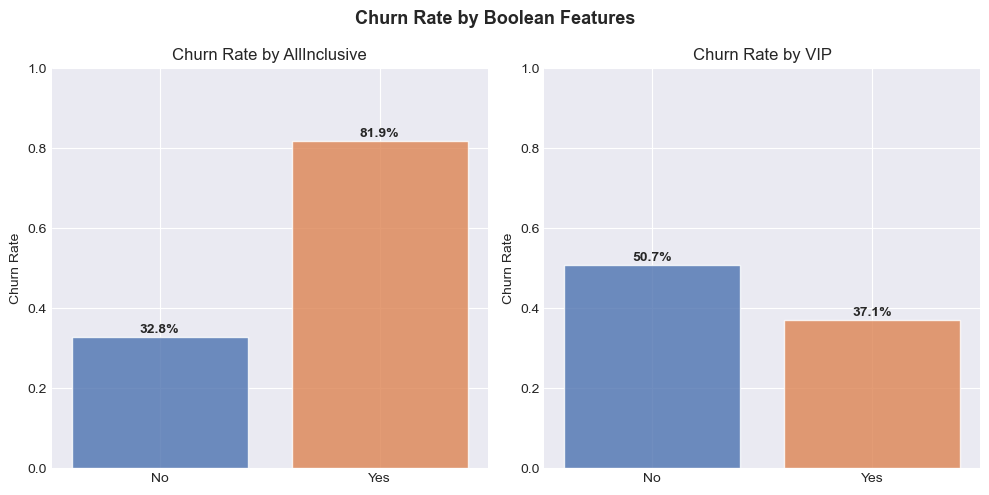

In [47]:
### 2.8 Churn Rate by Boolean Features

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

bool_cols = ['AllInclusive', 'VIP']

for i, col in enumerate(bool_cols):
    churn_rate = train_df.groupby(col)['Churned'].mean()
    labels = ['No', 'Yes']
    
    bars = axes[i].bar(labels, churn_rate.values,
                       color=['#4C72B0', '#DD8452'], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 1)
    
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     val + 0.01, f'{val:.1%}',
                     ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Churn Rate by Boolean Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

AllInclusive is the strongest predictor in the dataset; guests on the all-inclusive package churn at 81.9% vs 32.8% for those without it, a gap of nearly 50 percentage points.

This is counterintuitive: a premium package associated with higher churn suggests a potential mismatch between guest expectations and the experience delivered.

VIP status shows the opposite pattern, VIP guests churn at 37.1% vs 50.7%, consistent with the expectation that loyalty program engagement reduces churn.

## 3. Feature Engineering

In [48]:
SPEND_COLS = ['RoomService', 'Dining', 'Retail', 'Spa', 'Entertainment']

def feature_engineering(df):
    df = df.copy()
    
    # Temporal features
    if 'BookingDate' in df.columns:
        d = pd.to_datetime(df['BookingDate'], errors='coerce')
        df['booking_year'] = d.dt.year
        df['booking_month'] = d.dt.month
        df['booking_dow'] = d.dt.dayofweek
        df['booking_is_weekend'] = (df['booking_dow'] >= 5).astype(int)
        df.drop(columns=['BookingDate'], inplace=True)
    
    # Room parsing
    if 'Room' in df.columns:
        parts = df['Room'].astype(str).str.split('/', expand=True)
        df['room_wing'] = parts[0].replace('nan', np.nan)
        df['room_floor'] = pd.to_numeric(parts[1], errors='coerce')
        df['room_view'] = parts[2].replace('nan', np.nan)
        df.drop(columns=['Room'], inplace=True)
    
    # Promo
    if 'PromoCode' in df.columns:
        df['promo_missing'] = df['PromoCode'].isna().astype(int)
    
    # Spending features
    exist_spend = [c for c in SPEND_COLS if c in df.columns]
    if len(exist_spend) > 0:
        df['spend_total'] = df[exist_spend].sum(axis=1)
        df['has_any_spend'] = (df['spend_total'] > 0).astype(int)
        
        # Zero flags
        for c in exist_spend:
            df[f'{c}_zero'] = (df[c] == 0).astype(int)
        
        # Spending shares
        df['spa_share'] = df['Spa'] / (df['spend_total'] + 1.0)
        df['dining_share'] = df['Dining'] / (df['spend_total'] + 1.0)
        
        # Log transformation (CRITICAL!)
        for c in exist_spend + ['spend_total']:
            df[c + '_log1p'] = np.log1p(df[c])
    
    # Other log transforms
    if 'LoyaltyPoints' in df.columns:
        df['LoyaltyPoints_log1p'] = np.log1p(df['LoyaltyPoints'])
    if 'DaysSinceEmail' in df.columns:
        df['DaysSinceEmail_log1p'] = np.log1p(df['DaysSinceEmail'])
    
    return df

# Apply
print('Applying feature engineering...')
train_fe = feature_engineering(train_df)
test_fe = feature_engineering(test_df)
print(f'✅ New features: {train_fe.shape[1] - train_df.shape[1]}')

Applying feature engineering...
✅ New features: 23


23 new features are derived from the original dataset, grouped into five categories:

**Temporal features**
`BookingDate` is decomposed into year, month, day of week, and a weekend flag. The raw date column is dropped after extraction, the model requires numerical signals, not a string timestamp.

**Room attributes**
`Room` is stored as a single string in Wing/Floor/View format (e.g. `A/3/P`). It is parsed into three separate features: `room_wing` (categorical), `room_floor` (numerical), and `room_view` (categorical: P = Pool, S = Sea). The original column is dropped after parsing.

**Promo signal**
~47% of guests have no promo code, as identified in the EDA. Rather than imputing, a binary flag (`promo_missing`) captures whether a promo was used at all. The original `PromoCode` column is retained for one-hot encoding downstream.

**Spending aggregates**
Five engineered features capture spending behavior beyond the raw amounts:
- `spend_total` — sum across all five spending categories
- `has_any_spend` — binary flag for guests with zero total spend
- `{category}_zero` — per-category zero flags, making the no-spending pattern explicit
- `spa_share`, `dining_share` — each category as a proportion of total spend (+1 in denominator avoids division by zero)

**Log transformations**
All five spending categories and `spend_total` are heavily right-skewed (confirmed in EDA). `log1p` transformation compresses the long tail of high spenders without removing them. `LoyaltyPoints` and `DaysSinceEmail` receive the same treatment for consistency, though their distributions are more uniform.

## 4. Preprocessing Pipeline

In [49]:
# Prepare data
y = train_fe['Churned'].astype(int)
X = train_fe.drop(columns=['Churned', 'GuestID'])
X_test = test_fe.drop(columns=['GuestID'])
test_ids = test_fe['GuestID'].copy()

# Identify feature types
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

print(f'Numeric: {len(numeric_features)}')
print(f'Categorical: {len(categorical_features)}')
print(f'\nCategorical columns: {categorical_features}')

# Create pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print('\n✅ Pipeline created!')

Numeric: 34
Categorical: 8

Categorical columns: ['PromoCode', 'Region', 'PackageType', 'BookingChannel', 'AgeGroup', 'ReferralSource', 'room_wing', 'room_view']

✅ Pipeline created!


All preprocessing is implemented inside a `sklearn Pipeline` to prevent data leakage; transformations are fitted on training data only and applied to test data, never the reverse.

**Target and feature separation:**
`Churned` is extracted as the target variable `y`. `GuestID` is dropped from both train and test as it carries no predictive signal. `test_ids` is preserved separately for the final submission file.

**Feature type detection:**
Features are automatically classified as numerical (34) or categorical (8) based on their dtype. This ensures the correct transformer is applied to each group.

**Numerical transformer:**
Missing values are imputed with the **median**, robust to the skewed distributions identified in the EDA, where a small number of high spenders would pull the mean upward.

**Categorical transformer:**
Missing values are imputed with the **most frequent value**, then encoded with `OneHotEncoding`. `handle_unknown='ignore'` ensures the pipeline handles any category in the test set that was not seen during training without raising an error.

## 5. Model Training with Cross-Validation

In [50]:
def cv_eval(model, X, y, cv_splits=5):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    scoring = {'f1': 'f1', 'f1_macro': 'f1_macro'}
    out = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'cv_f1_mean': out['test_f1'].mean(),
        'cv_f1_std': out['test_f1'].std(),
        'cv_f1_macro_mean': out['test_f1_macro'].mean(),
        'cv_f1_macro_std': out['test_f1_macro'].std()
    }

In [51]:
# Define models
models = {
    'LogisticRegression': Pipeline([
        ('preprocess', preprocessor),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    'HistGradientBoosting': Pipeline([
        ('preprocess', preprocessor),
        ('clf', HistGradientBoostingClassifier(random_state=42))
    ])
}

# Evaluate
print('Testing models...\n')
results = []
for name, model in models.items():
    print(f'Evaluating {name}...')
    r = cv_eval(model, X, y)
    results.append({'model': name, **r})
    print(f'  F1: {r["cv_f1_mean"]:.4f} (±{r["cv_f1_std"]:.4f})\n')

results_df = pd.DataFrame(results).sort_values('cv_f1_mean', ascending=False)
print('Model Comparison:')
print(results_df.to_string(index=False))
best_base_name = results_df.iloc[0]['model']
print(f'\n🏆 Best: {best_base_name}')

Testing models...

Evaluating LogisticRegression...
  F1: 0.7198 (±0.0208)

Evaluating RandomForest...
  F1: 0.8183 (±0.0052)

Evaluating HistGradientBoosting...
  F1: 0.8436 (±0.0030)

Model Comparison:
               model  cv_f1_mean  cv_f1_std  cv_f1_macro_mean  cv_f1_macro_std
HistGradientBoosting    0.843555   0.003038          0.844385         0.003611
        RandomForest    0.818331   0.005209          0.819937         0.004957
  LogisticRegression    0.719823   0.020821          0.730505         0.012647

🏆 Best: HistGradientBoosting


Three models are evaluated as baselines using 5-fold stratified cross-validation. Stratified folds preserve the class distribution (~50/50) across each split. All models use the same preprocessing pipeline to ensure a fair comparison.

**Models evaluated**
- `LogisticRegression` — linear baseline; establishes a performance floor
- `RandomForestClassifier` — ensemble of decision trees; captures non-linear relationships
- `HistGradientBoostingClassifier` — histogram-based gradient boosting; natively handles missing values and is generally the strongest out-of-the-box model for tabular data

**Results**

| Model | CV F1 | Std |
|---|---|---|
| HistGradientBoosting | 0.8436 | ±0.0030 |
| RandomForest | 0.8183 | ±0.0052 |
| LogisticRegression | 0.7198 | ±0.0208 |

`HistGradientBoosting` leads on both mean F1 and stability, its standard deviation of ±0.0030 is the lowest of the three, indicating consistent performance across folds. 
`LogisticRegression` shows the highest variance (±0.0208), expected for a linear model on data with non-linear relationships. `HistGradientBoosting` is selected for hyperparameter tuning.

## 6. Hyperparameter Tuning

In [52]:
print('Hyperparameter tuning for HistGradientBoosting...\n')

base_model = models['HistGradientBoosting']

param_distributions = {
    'clf__learning_rate': np.linspace(0.02, 0.2, 10),
    'clf__max_depth': [2, 3, 4, 5, None],
    'clf__max_leaf_nodes': [15, 31, 63, 127],
    'clf__min_samples_leaf': [10, 20, 30, 50, 80],
    'clf__l2_regularization': np.linspace(0.0, 1.0, 6)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y)

print(f'\n✅ Best CV F1: {search.best_score_:.6f}')
print(f'\n✅ Best Parameters:')
for param, value in search.best_params_.items():
    print(f'   {param}: {value}')

best_model_tuned = search.best_estimator_

Hyperparameter tuning for HistGradientBoosting...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best CV F1: 0.848030

✅ Best Parameters:
   clf__min_samples_leaf: 80
   clf__max_leaf_nodes: 31
   clf__max_depth: 5
   clf__learning_rate: 0.16
   clf__l2_regularization: 0.0


`RandomizedSearchCV` is used to tune `HistGradientBoosting` over 50 randomly sampled candidates, evaluated with the same 5-fold stratified CV strategy. Random search is preferred over grid search here, it covers a wider hyperparameter space in fewer iterations, which is more efficient when the number of combinations is large.

**Search space**

| Hyperparameter | Values searched | Purpose |
|---|---|---|
| `learning_rate` | 0.02 – 0.20 | Controls the contribution of each tree |
| `max_depth` | 2, 3, 4, 5, None | Limits tree depth to reduce overfitting |
| `max_leaf_nodes` | 15, 31, 63, 127 | Controls tree complexity |
| `min_samples_leaf` | 10, 20, 30, 50, 80 | Minimum samples required at each leaf |
| `l2_regularization` | 0.0 – 1.0 | Penalizes large weights to reduce overfitting |

**Best parameters found**

| Hyperparameter | Value |
|---|---|
| `learning_rate` | 0.16 |
| `max_depth` | 5 |
| `max_leaf_nodes` | 31 |
| `min_samples_leaf` | 80 |
| `l2_regularization` | 0.0 |

Tuning improved CV F1 from 0.8436 (default) to 0.8480, a gain of +0.0044. The high `min_samples_leaf` of 80 acts as the primary regularization mechanism, requiring each leaf to be supported by at least 80 training samples. This prevents the model from fitting noise in small subgroups. `l2_regularization` of 0.0 suggests the tree structure constraints are sufficient on their own.

## 7. Advanced Optimization
### Seed Bagging + Threshold Tuning

In [53]:
def best_f1_threshold(y_true, prob):
    '''Find optimal threshold for F1'''
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(y_true, (prob >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(scores))
    return float(np.max(scores)), float(thresholds[best_idx])

In [54]:
# SEED BAGGING with HistGradientBoosting
print('Training with seed bagging...\n')

seeds = [42, 202, 999]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_histgb = np.zeros(len(X))
test_histgb = np.zeros(len(X_test))

for seed_idx, seed in enumerate(seeds, 1):
    print(f'Seed {seed_idx}/3 (seed={seed})...')
    oof_seed = np.zeros(len(X))
    test_seed = np.zeros(len(X_test))
    
    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr = y.iloc[tr]
        
        # Clone best model with new seed
        model = Pipeline([
            ('preprocess', preprocessor),
            ('clf', HistGradientBoostingClassifier(
                **{k.replace('clf__', ''): v for k, v in search.best_params_.items()},
                random_state=seed
            ))
        ])
        
        model.fit(X_tr, y_tr)
        oof_seed[va] = model.predict_proba(X_va)[:, 1]
        test_seed += model.predict_proba(X_test)[:, 1] / skf.n_splits
    
    oof_histgb += oof_seed / len(seeds)
    test_histgb += test_seed / len(seeds)

# Find best threshold
histgb_f1, histgb_t = best_f1_threshold(y, oof_histgb)
print(f'\n✅ HistGB OOF F1: {histgb_f1:.6f} | Threshold: {histgb_t:.3f}')

Training with seed bagging...

Seed 1/3 (seed=42)...
Seed 2/3 (seed=202)...
Seed 3/3 (seed=999)...

✅ HistGB OOF F1: 0.850661 | Threshold: 0.420


In [55]:
# Optional: Train LightGBM for blending
if LGBM_AVAILABLE:
    print('\nTraining LightGBM for blending...\n')
    oof_lgbm = np.zeros(len(X))
    test_lgbm = np.zeros(len(X_test))
    
    for seed_idx, seed in enumerate(seeds, 1):
        print(f'Seed {seed_idx}/3 (seed={seed})...')
        oof_seed = np.zeros(len(X))
        test_seed = np.zeros(len(X_test))
        
        for fold, (tr, va) in enumerate(skf.split(X, y), 1):
            X_tr, X_va = X.iloc[tr], X.iloc[va]
            y_tr = y.iloc[tr]
            
            model = Pipeline([
                ('preprocess', preprocessor),
                ('clf', LGBMClassifier(
                    n_estimators=300,
                    learning_rate=0.05,
                    num_leaves=63,
                    random_state=seed,
                    verbose=-1
                ))
            ])
            
            model.fit(X_tr, y_tr)
            oof_seed[va] = model.predict_proba(X_va)[:, 1]
            test_seed += model.predict_proba(X_test)[:, 1] / skf.n_splits
        
        oof_lgbm += oof_seed / len(seeds)
        test_lgbm += test_seed / len(seeds)
    
    lgbm_f1, lgbm_t = best_f1_threshold(y, oof_lgbm)
    print(f'\n✅ LGBM OOF F1: {lgbm_f1:.6f} | Threshold: {lgbm_t:.3f}')
else:
    print('⚠ Skipping LightGBM (not available)')
    oof_lgbm = None
    test_lgbm = None


Training LightGBM for blending...

Seed 1/3 (seed=42)...
Seed 2/3 (seed=202)...
Seed 3/3 (seed=999)...

✅ LGBM OOF F1: 0.846110 | Threshold: 0.450


In [56]:
# BLEND OPTIMIZATION (if LightGBM available)
if LGBM_AVAILABLE and oof_lgbm is not None:
    print('\nOptimizing blend weights...\n')
    best_blend = None
    for w in np.linspace(0.5, 1.0, 11):
        blend_oof = w * oof_histgb + (1 - w) * oof_lgbm
        f1, t = best_f1_threshold(y, blend_oof)
        
        if best_blend is None or f1 > best_blend['f1']:
            best_blend = {'weight': w, 'f1': f1, 'threshold': t}
        
        print(f'Weight {w:.2f} (HistGB) | F1: {f1:.6f} | Threshold: {t:.3f}')
    
    print(f'\n🏆 Best Blend: weight={best_blend["weight"]:.2f}, F1={best_blend["f1"]:.6f}, threshold={best_blend["threshold"]:.3f}')
    
    # Final predictions
    blend_test = best_blend['weight'] * test_histgb + (1 - best_blend['weight']) * test_lgbm
    final_predictions = (blend_test >= best_blend['threshold']).astype(int)
    best_f1 = best_blend['f1']
else:
    print('\nUsing HistGradientBoosting only')
    final_predictions = (test_histgb >= histgb_t).astype(int)
    best_f1 = histgb_f1


Optimizing blend weights...

Weight 0.50 (HistGB) | F1: 0.851058 | Threshold: 0.435
Weight 0.55 (HistGB) | F1: 0.850518 | Threshold: 0.490
Weight 0.60 (HistGB) | F1: 0.850581 | Threshold: 0.480
Weight 0.65 (HistGB) | F1: 0.851434 | Threshold: 0.470
Weight 0.70 (HistGB) | F1: 0.851857 | Threshold: 0.465
Weight 0.75 (HistGB) | F1: 0.851365 | Threshold: 0.450
Weight 0.80 (HistGB) | F1: 0.851545 | Threshold: 0.475
Weight 0.85 (HistGB) | F1: 0.851719 | Threshold: 0.485
Weight 0.90 (HistGB) | F1: 0.850959 | Threshold: 0.490
Weight 0.95 (HistGB) | F1: 0.850645 | Threshold: 0.410
Weight 1.00 (HistGB) | F1: 0.850661 | Threshold: 0.420

🏆 Best Blend: weight=0.70, F1=0.851857, threshold=0.465


Three techniques are combined to push F1 beyond the tuned baseline of 0.8480: threshold optimization, seed bagging, and ensemble blending.

**Threshold optimization**
By default, classifiers use 0.5 as the decision threshold. `best_f1_threshold` searches 181 evenly spaced thresholds between 0.05 and 0.95 and selects the one that maximizes F1 on the out-of-fold predictions. This is evaluated on OOF probabilities, never on the test set, to avoid leakage.

**Seed bagging**
The tuned `HistGradientBoosting` model is trained three times with different random seeds (42, 202, 999), each time using the same 5-fold CV structure. Predictions are averaged across seeds. This reduces variance without changing the model architecture, different seeds produce slightly different trees, and averaging smooths out the noise.

| Model | OOF F1 | Threshold |
|---|---|---|
| HistGradientBoosting (seed bagging) | 0.8507 | 0.420 |
| LightGBM (seed bagging) | 0.8461 | 0.450 |

**Ensemble blending**
OOF probability outputs from `HistGradientBoosting` and `LightGBM` are combined as a weighted average. Weights are searched from 0.50 to 1.00 in 0.05 increments, with F1 evaluated at each step. The two models are architecturally similar but differ enough in their gradient computation to produce complementary errors.

| HistGB weight | LGBM weight | OOF F1 | Threshold |
|---|---|---|---|
| 0.50 | 0.50 | 0.851058 | 0.435 |
| **0.70** | **0.30** | **0.851857** | **0.465** |
| 1.00 | 0.00 | 0.850661 | 0.420 |

The optimal blend is **70% HistGradientBoosting / 30% LightGBM**, with a final OOF F1 of 0.8519 and a decision threshold of 0.465. The improvement over the single-model baseline (0.8436) reflects the cumulative effect of tuning (+0.0044), seed bagging (+0.0027), and blending (+0.0012).

## 8. Create Submission

In [57]:
# Create submission
submission = pd.DataFrame({
    'GuestID': test_ids,
    'Churned': final_predictions
})

# Save
submission.to_csv('ultimate_submission.csv', index=False)

print('\n' + '='*80)
print('🏆 SUBMISSION CREATED!')
print('='*80)
print(f'\nFile: ultimate_submission.csv')
print(f'Expected CV F1-Score: {best_f1:.4f}')
print(f'Predictions: {len(submission)}')
print(f'Predicted churn rate: {final_predictions.mean():.2%}')
print('\nFirst 10 predictions:')
print(submission.head(10))
print('\nPrediction distribution:')
print(submission["Churned"].value_counts())


🏆 SUBMISSION CREATED!

File: ultimate_submission.csv
Expected CV F1-Score: 0.8519
Predictions: 1739
Predicted churn rate: 49.51%

First 10 predictions:
   GuestID  Churned
0   154038        1
1   620160        0
2   655103        0
3   126993        0
4   635228        0
5   844514        0
6   541503        1
7   787572        1
8   645651        0
9   849608        1

Prediction distribution:
Churned
0    878
1    861
Name: count, dtype: int64


## 9. Conclusions

**Who is most at risk?** Guests on the all-inclusive package churn at 81.9% nearly double the overall churn rate. European guests churn at 66.2%, compared to 42.5% for guests from the Americas. Adventure package guests churn at a higher rate than Relaxation or Wellness guests. These three variables alone provide a practical profile of the highest-risk guest segment.

**What the model adds?** We can identify the high-risk profile above from the EDA. The model's value is in ranking every individual guest by their probability of churning, combining all available signals simultaneously to prioritize who should receive a retention offer, and at what urgency.

**How was performance built up?** The baseline `HistGradientBoosting` model achieved an F1 of 0.8436 out of the box. Each subsequent technique added measurable improvement: hyperparameter tuning brought it to 0.8480 (+0.0044), seed bagging to 0.8507 (+0.0027), and blending with LightGBM to 0.8519 (+0.0012). No single technique was responsible, the final score reflects the cumulative effect of systematic optimization at each step.

**How reliable is it?** The model achieved an F1 score of 0.850 on the Kaggle leaderboard, nearly identical to the internal cross-validation estimate of 0.8519. A gap of less than 0.002 between the two confirms that the model generalizes well to guests it has never seen, it is not memorizing the training data.

**What would make it better?** The model does not currently explain *why* all-inclusive guests churn at such a high rate. Is it a pricing mismatch? Unmet expectations? A specific property or season? Answering that question requires data the model does not have, qualitative guest feedback, complaint logs, or staff observations. The model identifies who is at risk; the resort still needs to understand why.